## 1. Generating Random Networks

### ER model

--- ER Network with n=900, p=0.002 ---
Empirical Mean     : 1.8000 | Theoretical Mean     : 1.7980
Empirical Variance : 1.8200 | Theoretical Variance : 1.7944

--- ER Network with n=900, p=0.006 ---
Empirical Mean     : 5.4711 | Theoretical Mean     : 5.3940
Empirical Variance : 5.6758 | Theoretical Variance : 5.3616

--- ER Network with n=900, p=0.012 ---
Empirical Mean     : 10.6800 | Theoretical Mean     : 10.7880
Empirical Variance : 9.3932 | Theoretical Variance : 10.6585

--- ER Network with n=900, p=0.045 ---
Empirical Mean     : 40.7067 | Theoretical Mean     : 40.4550
Empirical Variance : 39.1140 | Theoretical Variance : 38.6345

--- ER Network with n=900, p=0.1 ---
Empirical Mean     : 89.4111 | Theoretical Mean     : 89.9000
Empirical Variance : 80.5177 | Theoretical Variance : 80.9100



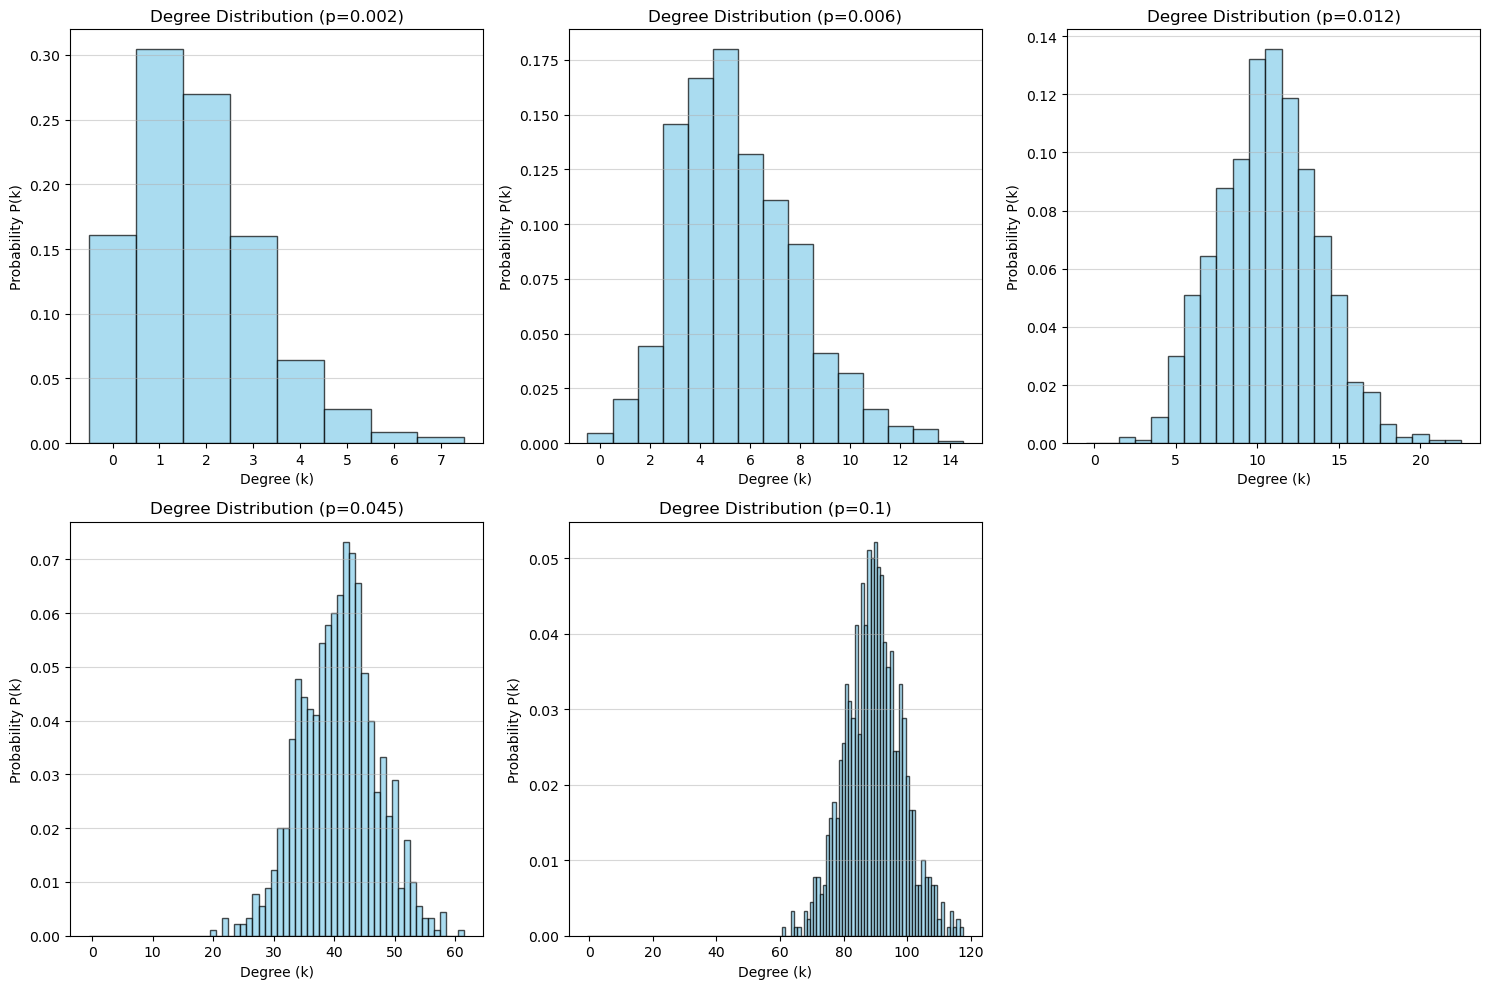

In [ ]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, p in enumerate(p_values):
    g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)
    
    degrees = g.degree()
    
    emp_mean = np.mean(degrees)
    emp_var = np.var(degrees)
    
    theo_mean = (n - 1) * p
    theo_var = (n - 1) * p * (1 - p)
    
    print(f"--- ER Network with n={n}, p={p} ---")
    print(f"Empirical Mean     : {emp_mean:.4f} | Theoretical Mean     : {theo_mean:.4f}")
    print(f"Empirical Variance : {emp_var:.4f} | Theoretical Variance : {theo_var:.4f}\n")
    
    max_deg = max(degrees) if len(degrees) > 0 else 1
    bins = np.arange(-0.5, max_deg + 1.5, 1)
    
    axes[i].hist(degrees, bins=bins, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f"Degree Distribution (p={p})")
    axes[i].set_xlabel("Degree (k)")
    axes[i].set_ylabel("Probability P(k)")
    axes[i].grid(axis='y', alpha=0.5)

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('images/part1_1a_degree_distributions.png', dpi=300)
plt.show()

In [ ]:
import igraph as ig

n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]
num_trials = 100

print(f"{'p_value':<10} | {'Prob of Connected':<20} | {'GCC Size (1 instance)':<25} | {'GCC Diameter'}")
print("-" * 80)

for p in p_values:
    connected_count = 0
    for _ in range(num_trials):
        g_sim = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)
        if g_sim.is_connected():
            connected_count += 1
            
    prob_connected = connected_count / num_trials
    
    g_inst = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)
    
    if g_inst.is_connected():
        gcc_size = g_inst.vcount()
        gcc_diameter = g_inst.diameter()
    else:
        components = g_inst.connected_components()
        gcc = components.giant()
        gcc_size = gcc.vcount()
        gcc_diameter = gcc.diameter()
        
    print(f"{p:<10} | {prob_connected:<20.4f} | {gcc_size:<25} | {gcc_diameter}")

p_value    | Prob of Connected    | GCC Size (1 instance)     | GCC Diameter
--------------------------------------------------------------------------------
0.002      | 0.0000               | 662                       | 27
0.006      | 0.0300               | 895                       | 8
0.012      | 0.9800               | 900                       | 5
0.045      | 1.0000               | 900                       | 3
0.1        | 1.0000               | 900                       | 3


Simulating 100 networks for each p. This might take a minute...


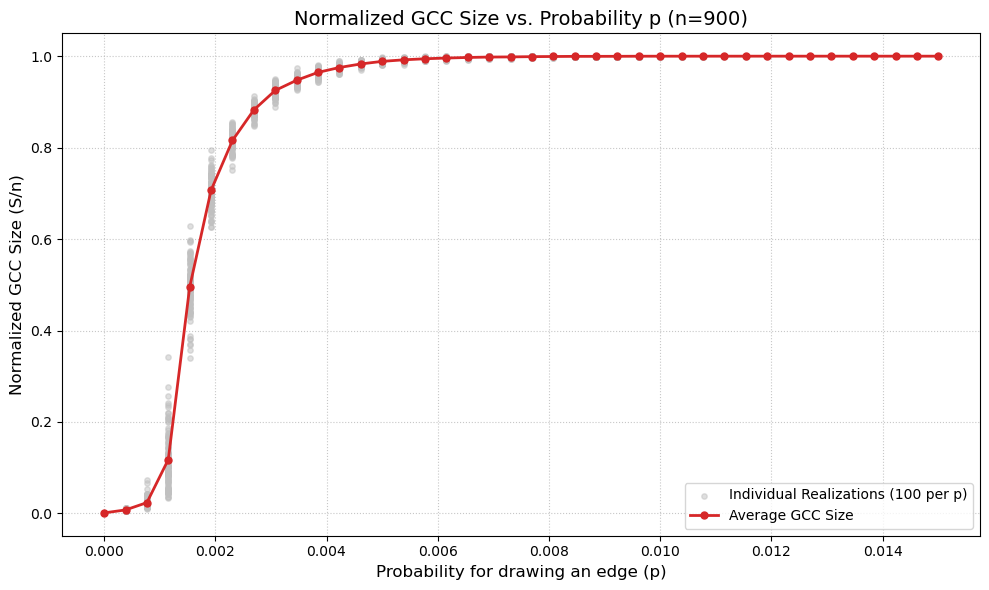


--- Corrected Data for Report Analysis ---
Emergence observation: At p=0.0012, Average GCC = 11.8%
Over 99% observation : At p=0.0058, 95/100 experiments have GCC > 99%


In [7]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

n = 900
# Determine p_max based on the theoretical connected threshold O(ln(n)/n) ~ 0.0075
p_max = 0.015
# Sweep over values of p
p_values = np.linspace(0, p_max, 40)
num_trials = 100

all_p_points = []
all_gcc_sizes = []
avg_gcc_sizes = []

print("Simulating 100 networks for each p. This might take a minute...")

for p in p_values:
    current_p_gccs = []
    for _ in range(num_trials):
        g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)
        components = g.connected_components()
        
        if len(components) > 0:
            gcc_size = max(components.sizes()) / n
        else:
            gcc_size = 0
            
        current_p_gccs.append(gcc_size)
        all_p_points.append(p)
        all_gcc_sizes.append(gcc_size)
        
    avg_gcc_sizes.append(np.mean(current_p_gccs))

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot of all 100 random networks for each p
ax.scatter(all_p_points, all_gcc_sizes, color='silver', alpha=0.5, s=15, 
           label='Individual Realizations (100 per p)')

# Line plot of the average normalized GCC sizes
ax.plot(p_values, avg_gcc_sizes, color='tab:red', marker='o', 
        linestyle='-', linewidth=2, markersize=5, label='Average GCC Size')

ax.set_title("Normalized GCC Size vs. Probability p (n=900)", fontsize=14)
ax.set_xlabel("Probability for drawing an edge (p)", fontsize=12)
ax.set_ylabel("Normalized GCC Size (S/n)", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.savefig('images/part1_1c_scatter_plot.png', dpi=300)
plt.show()

# --- Print helper data for report writing ---
print("\n--- Corrected Data for Report Analysis ---")

for i, p in enumerate(p_values):
    # Criterion for emergence: average GCC size exceeds 5%
    if 0.05 < avg_gcc_sizes[i] < 0.2:
        print(f"Emergence observation: At p={p:.4f}, Average GCC = {avg_gcc_sizes[i]*100:.1f}%")
        
    # Corrected criterion for almost surely connected: >99% in almost every experiment (e.g., >= 95 out of 100 trials)
    # We need to slice the all_gcc_sizes list to get the 100 trials for THIS specific p
    start_idx = i * num_trials
    end_idx = start_idx + num_trials
    trials_for_this_p = all_gcc_sizes[start_idx:end_idx]
    
    success_count = sum(1 for size in trials_for_this_p if size > 0.99)
    
    if success_count >= 95:
        print(f"Over 99% observation : At p={p:.4f}, {success_count}/100 experiments have GCC > 99%")
        break

Simulating networks. This will generate 5000 graphs, please wait...


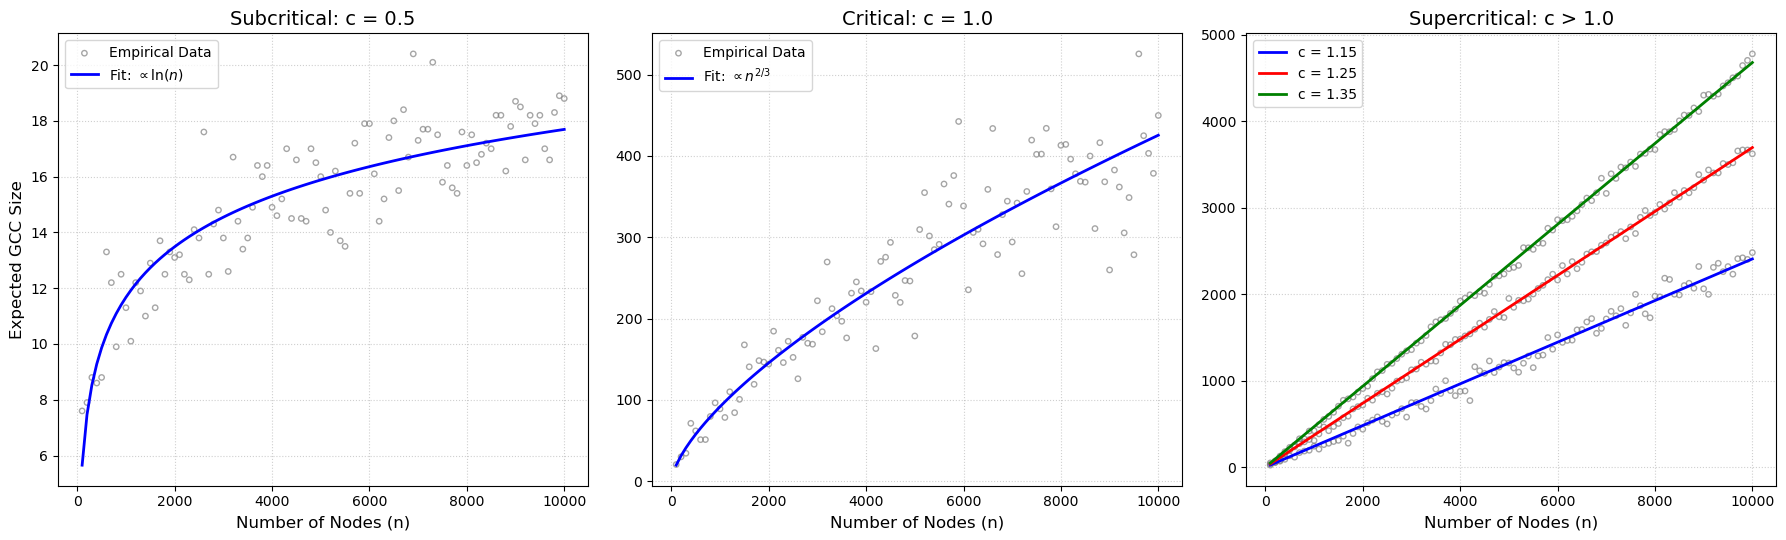

In [2]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

os.makedirs('images', exist_ok=True)

# 1. High-density sampling: 100 points between 100 and 10000
n_values = np.linspace(100, 10000, 100).astype(int)
num_trials = 10  # 10 trials per point is enough since we have 100 points

def get_expected_gcc_size(n_array, c, trials):
    expected_sizes = []
    for n in n_array:
        p = c / n
        current_n_sizes = []
        for _ in range(trials):
            g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False)
            components = g.connected_components()
            if len(components) > 0:
                current_n_sizes.append(max(components.sizes()))
            else:
                current_n_sizes.append(0)
        expected_sizes.append(np.mean(current_n_sizes))
    return np.array(expected_sizes)

print("Simulating networks. This will generate 5000 graphs, please wait...")

gcc_c05 = get_expected_gcc_size(n_values, 0.5, num_trials)
gcc_c10 = get_expected_gcc_size(n_values, 1.0, num_trials)
gcc_c115 = get_expected_gcc_size(n_values, 1.15, num_trials)
gcc_c125 = get_expected_gcc_size(n_values, 1.25, num_trials)
gcc_c135 = get_expected_gcc_size(n_values, 1.35, num_trials)

# 2. Define Theoretical Fitting Functions
def fit_subcritical(x, a, b): return a * np.log(x) + b
def fit_critical(x, a): return a * (x ** (2/3))
def fit_supercritical(x, a): return a * x

# Fit the data
popt_c05, _ = curve_fit(fit_subcritical, n_values, gcc_c05)
popt_c10, _ = curve_fit(fit_critical, n_values, gcc_c10)
popt_c115, _ = curve_fit(fit_supercritical, n_values, gcc_c115)
popt_c125, _ = curve_fit(fit_supercritical, n_values, gcc_c125)
popt_c135, _ = curve_fit(fit_supercritical, n_values, gcc_c135)

# 3. Plotting in the exact style of the reference report
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

scatter_kwargs = {'facecolors': 'none', 'edgecolors': 'gray', 's': 15, 'alpha': 0.7}

# Plot 1: Subcritical (c = 0.5)
axes[0].scatter(n_values, gcc_c05, **scatter_kwargs, label='Empirical Data')
axes[0].plot(n_values, fit_subcritical(n_values, *popt_c05), color='blue', linewidth=2, label=r'Fit: $\propto \ln(n)$')
axes[0].set_title('Subcritical: c = 0.5', fontsize=14)
axes[0].set_xlabel('Number of Nodes (n)', fontsize=12)
axes[0].set_ylabel('Expected GCC Size', fontsize=12)
axes[0].legend()

# Plot 2: Critical (c = 1.0)
axes[1].scatter(n_values, gcc_c10, **scatter_kwargs, label='Empirical Data')
axes[1].plot(n_values, fit_critical(n_values, *popt_c10), color='blue', linewidth=2, label=r'Fit: $\propto n^{2/3}$')
axes[1].set_title('Critical: c = 1.0', fontsize=14)
axes[1].set_xlabel('Number of Nodes (n)', fontsize=12)
axes[1].legend()

# Plot 3: Supercritical (c > 1.0)
axes[2].scatter(n_values, gcc_c115, **scatter_kwargs)
axes[2].plot(n_values, fit_supercritical(n_values, *popt_c115), color='blue', linewidth=2, label='c = 1.15')

axes[2].scatter(n_values, gcc_c125, **scatter_kwargs)
axes[2].plot(n_values, fit_supercritical(n_values, *popt_c125), color='red', linewidth=2, label='c = 1.25')

axes[2].scatter(n_values, gcc_c135, **scatter_kwargs)
axes[2].plot(n_values, fit_supercritical(n_values, *popt_c135), color='green', linewidth=2, label='c = 1.35')

axes[2].set_title('Supercritical: c > 1.0', fontsize=14)
axes[2].set_xlabel('Number of Nodes (n)', fontsize=12)
axes[2].legend()

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('images/part1_1d_gcc_scaling.png', dpi=300)
plt.show()

### BA model

Generating BA Networks. Please wait...

--- Network Metrics ---
Connected (n=1050 )     : True
Modularity (n=1050 )    : 0.9362
Assortativity (n=1050 ) : -0.1080
------------------------------
Connected (n=10500)     : True
Modularity (n=10500)    : 0.9785
Assortativity (n=10500) : -0.0176

--- Power-law Exponent Estimates ---
Estimated Slope (n=1050 ) : -2.2769
Estimated Slope (n=10500) : -2.6899


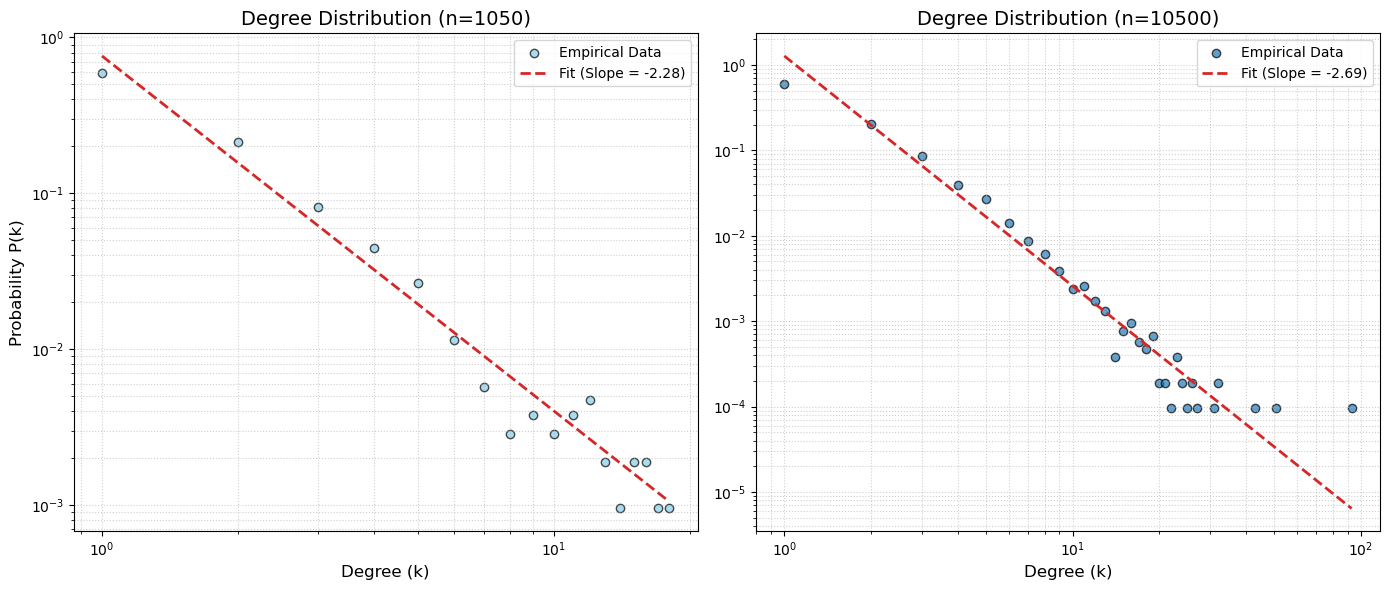

In [6]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

os.makedirs('images', exist_ok=True)

# --- Parameters ---
n_small = 1050
n_large = 10500
m_val = 1

# --- Part 2 2(a) & 2(c): Network Generation & Metrics ---
print("Generating BA Networks. Please wait...")
g_small = ig.Graph.Barabasi(n=n_small, m=m_val, directed=False)
g_large = ig.Graph.Barabasi(n=n_large, m=m_val, directed=False)

is_connected_small = g_small.is_connected()
is_connected_large = g_large.is_connected()

# Simplify to ensure robust fastgreedy calculation
g_small.simplify(multiple=True, loops=True)
g_large.simplify(multiple=True, loops=True)

mod_small = g_small.community_fastgreedy().as_clustering().modularity
mod_large = g_large.community_fastgreedy().as_clustering().modularity

assort_small = g_small.assortativity_degree()
assort_large = g_large.assortativity_degree()

print("\n--- Network Metrics ---")
print(f"Connected (n={n_small:<5})     : {is_connected_small}")
print(f"Modularity (n={n_small:<5})    : {mod_small:.4f}")
print(f"Assortativity (n={n_small:<5}) : {assort_small:.4f}")
print("-" * 30)
print(f"Connected (n={n_large:<5})     : {is_connected_large}")
print(f"Modularity (n={n_large:<5})    : {mod_large:.4f}")
print(f"Assortativity (n={n_large:<5}) : {assort_large:.4f}")

# --- Part 2 2(d): Degree Distribution & Robust Regression ---
def analyze_degree_distribution(graph):
    degrees = graph.degree()
    counts = Counter(degrees)
    
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[k] / graph.vcount() for k in x])
    
    # Robust Linear Regression: Filter out the noisy tail.
    # We only fit the line to degrees that appear at least 2 times.
    # This prevents the flat tail (p = 1/N) from artificially lowering the slope.
    valid_for_fit = np.array([counts[k] >= 2 for k in x])
    
    log_x = np.log10(x[valid_for_fit])
    log_y = np.log10(y[valid_for_fit])
    
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    return x, y, slope, intercept

x_small, y_small, slope_small, int_small = analyze_degree_distribution(g_small)
x_large, y_large, slope_large, int_large = analyze_degree_distribution(g_large)

print("\n--- Power-law Exponent Estimates ---")
print(f"Estimated Slope (n={n_small:<5}) : {slope_small:.4f}")
print(f"Estimated Slope (n={n_large:<5}) : {slope_large:.4f}")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Small Network
axes[0].scatter(x_small, y_small, color='skyblue', alpha=0.7, edgecolors='k', label='Empirical Data')
axes[0].plot(x_small, (10**int_small) * (x_small**slope_small), color='tab:red', linestyle='--', linewidth=2, label=f'Fit (Slope = {slope_small:.2f})')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title(f"Degree Distribution (n={n_small})", fontsize=14)
axes[0].set_xlabel("Degree (k)", fontsize=12)
axes[0].set_ylabel("Probability P(k)", fontsize=12)
axes[0].grid(True, which='both', linestyle=':', alpha=0.6)
axes[0].legend()

# Plot Large Network
axes[1].scatter(x_large, y_large, color='tab:blue', alpha=0.7, edgecolors='k', label='Empirical Data')
axes[1].plot(x_large, (10**int_large) * (x_large**slope_large), color='tab:red', linestyle='--', linewidth=2, label=f'Fit (Slope = {slope_large:.2f})')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title(f"Degree Distribution (n={n_large})", fontsize=14)
axes[1].set_xlabel("Degree (k)", fontsize=12)
axes[1].grid(True, which='both', linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/part2_2d_degree_distribution_comparison.png', dpi=300)
plt.show()

STARTING PART 2(e) - 2(h) COMPREHENSIVE SIMULATION
Generating BA Networks for m=1, 2, 6...

[Part 2g] Network Metrics (Modularity & Assortativity)
  m=2 | n=1050  -> Modularity: 0.5260, Assortativity: -0.0323
  m=2 | n=10500 -> Modularity: 0.5309, Assortativity: -0.0025
  m=6 | n=1050  -> Modularity: 0.2503, Assortativity: -0.0300
  m=6 | n=10500 -> Modularity: 0.2487, Assortativity: -0.0012

[Part 2g] Standard Degree Distribution Slopes (Log-Log)
  m=2 | n=1050  Slope: -2.3877
  m=2 | n=10500 Slope: -2.6925
  m=6 | n=1050  Slope: -2.1052
  m=6 | n=10500 Slope: -2.5051

[Part 2e & 2g] Neighbor Degree Distribution Slopes (The Friendship Paradox)
  m=1 | n=1050  Neighbor Slope: -0.9976
  m=1 | n=10500 Neighbor Slope: -1.3603
  m=2 | n=1050  Neighbor Slope: -1.0944
  m=2 | n=10500 Neighbor Slope: -1.3992
  m=6 | n=1050  Neighbor Slope: -0.8890
  m=6 | n=10500 Neighbor Slope: -1.1279

[Part 2f & 2g] Expected Degree vs Age Slopes (Log-Log, 50 trials)
  m=1 | n=1050  Expected Degree vs Age S

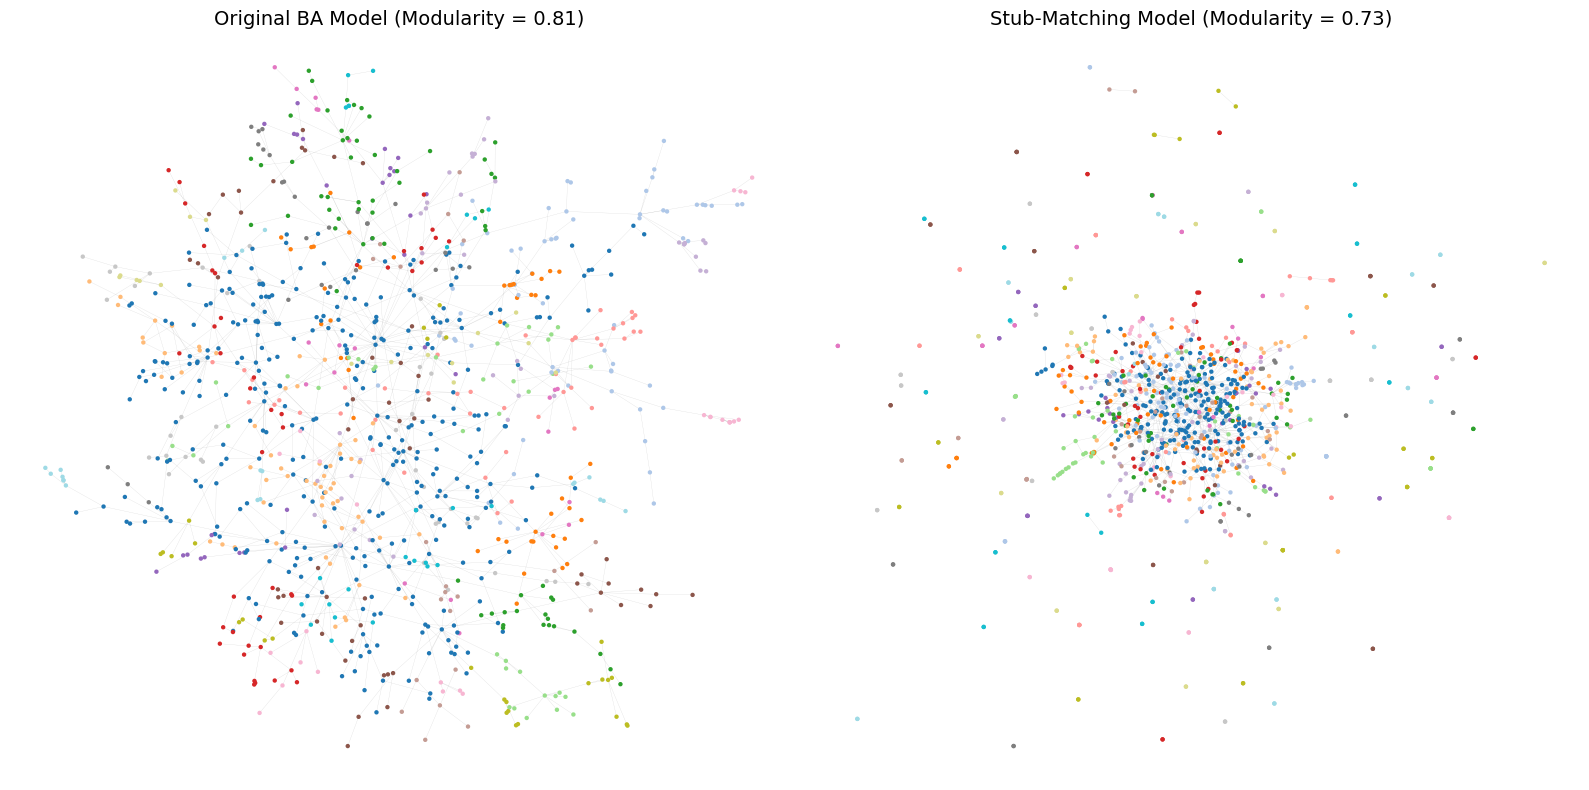

All tasks completed successfully. Images saved to images/ directory.


In [15]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
from collections import Counter
import os

os.makedirs('images', exist_ok=True)

# ==========================================
# Parameters & Helper Functions
# ==========================================
n_small = 1050
n_large = 10500

def analyze_degree(graph):
    """Returns degree distribution data and robust log-log linear fit slope."""
    degrees = graph.degree()
    counts = Counter(degrees)
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[k] / graph.vcount() for k in x])
    
    # Filter tail noise (keep degrees appearing >= 2 times)
    valid = np.array([counts[k] >= 2 for k in x])
    if sum(valid) < 2: valid = np.array([counts[k] >= 1 for k in x])
        
    log_x, log_y = np.log10(x[valid]), np.log10(y[valid])
    slope, intercept = np.polyfit(log_x, log_y, 1)
    return x, y, slope, intercept

def analyze_neighbor_degree(graph, num_samples=50000):
    """Simulates random walk (1 step) to find neighbor degree distribution."""
    degrees = np.array(graph.degree())
    valid_nodes = np.where(degrees > 0)[0]
    sampled_degrees = []
    
    for _ in range(num_samples):
        i = np.random.choice(valid_nodes)
        neighbors = graph.neighbors(i)
        if len(neighbors) > 0:
            j = np.random.choice(neighbors)
            sampled_degrees.append(degrees[j])
            
    counts = Counter(sampled_degrees)
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[k] / len(sampled_degrees) for k in x])
    
    valid = (x > 0) & (y > 0)
    log_x, log_y = np.log10(x[valid]), np.log10(y[valid])
    slope, intercept = np.polyfit(log_x, log_y, 1)
    return x, y, slope, intercept

# ==========================================
# Execution & Terminal Outputs
# ==========================================
print("="*50)
print("STARTING PART 2(e) - 2(h) COMPREHENSIVE SIMULATION")
print("="*50)

# Generate Base Networks
print("Generating BA Networks for m=1, 2, 6...")
graphs = {
    1: {'s': ig.Graph.Barabasi(n=n_small, m=1, directed=False), 'l': ig.Graph.Barabasi(n=n_large, m=1, directed=False)},
    2: {'s': ig.Graph.Barabasi(n=n_small, m=2, directed=False), 'l': ig.Graph.Barabasi(n=n_large, m=2, directed=False)},
    6: {'s': ig.Graph.Barabasi(n=n_small, m=6, directed=False), 'l': ig.Graph.Barabasi(n=n_large, m=6, directed=False)}
}

# Simplify networks for robust community detection
for m in [1, 2, 6]:
    graphs[m]['s'].simplify(multiple=True, loops=True)
    graphs[m]['l'].simplify(multiple=True, loops=True)

# --- 2(g): Modularity & Assortativity for m=2, 6 ---
print("\n[Part 2g] Network Metrics (Modularity & Assortativity)")
for m in [2, 6]:
    mod_s = graphs[m]['s'].community_fastgreedy().as_clustering().modularity
    mod_l = graphs[m]['l'].community_fastgreedy().as_clustering().modularity
    assort_s = graphs[m]['s'].assortativity_degree()
    assort_l = graphs[m]['l'].assortativity_degree()
    print(f"  m={m} | n={n_small:<5} -> Modularity: {mod_s:.4f}, Assortativity: {assort_s:.4f}")
    print(f"  m={m} | n={n_large:<5} -> Modularity: {mod_l:.4f}, Assortativity: {assort_l:.4f}")

# --- 2(g): Standard Degree Distribution Slopes ---
print("\n[Part 2g] Standard Degree Distribution Slopes (Log-Log)")
deg_results = {}
for m in [2, 6]:
    deg_results[m] = {
        's': analyze_degree(graphs[m]['s']),
        'l': analyze_degree(graphs[m]['l'])
    }
    print(f"  m={m} | n={n_small:<5} Slope: {deg_results[m]['s'][2]:.4f}")
    print(f"  m={m} | n={n_large:<5} Slope: {deg_results[m]['l'][2]:.4f}")

# --- 2(e) & 2(g): Neighbor Degree Distribution Slopes ---
print("\n[Part 2e & 2g] Neighbor Degree Distribution Slopes (The Friendship Paradox)")
nn_results = {}
for m in [1, 2, 6]:
    nn_results[m] = {
        's': analyze_neighbor_degree(graphs[m]['s']),
        'l': analyze_neighbor_degree(graphs[m]['l'])
    }
    print(f"  m={m} | n={n_small:<5} Neighbor Slope: {nn_results[m]['s'][2]:.4f}")
    print(f"  m={m} | n={n_large:<5} Neighbor Slope: {nn_results[m]['l'][2]:.4f}")

# --- 2(f) & 2(g): Expected Degree vs Age Slopes ---
print("\n[Part 2f & 2g] Expected Degree vs Age Slopes (Log-Log, 50 trials)")
exp_deg_results = {}
node_indices = np.arange(1, n_small + 1)
log_i = np.log10(node_indices)

for m in [1, 2, 6]:
    deg_matrix = np.zeros((50, n_small))
    for t in range(50):
        deg_matrix[t, :] = ig.Graph.Barabasi(n=n_small, m=m, directed=False).degree()
    
    expected_k = np.mean(deg_matrix, axis=0)
    slope, intercept = np.polyfit(log_i, np.log10(expected_k), 1)
    exp_deg_results[m] = (expected_k, slope, intercept)
    print(f"  m={m} | n={n_small:<5} Expected Degree vs Age Slope: {slope:.4f} (Theoretical: -0.50)")

# --- 2(h): BA vs Stub-matching Modularity ---
print("\n[Part 2h] BA vs Stub-Matching (Configuration Model)")
g_ba = ig.Graph.Barabasi(n=n_small, m=1, directed=False)
deg_seq = g_ba.degree()
g_stub = ig.Graph.Degree_Sequence(deg_seq, method="simple")

# Using Walktrap as suggested by the hint to handle multi-edges safely
wt_ba = g_ba.community_walktrap().as_clustering()
wt_stub = g_stub.community_walktrap().as_clustering()

print(f"  Modularity (Original BA)   : {wt_ba.modularity:.4f}")
print(f"  Modularity (Stub-Matching) : {wt_stub.modularity:.4f}")
print("="*50)


# ==========================================
# Plotting Section
# ==========================================
print("Generating and saving plots to images/ directory...")

# 1. Standard Degree Distribution (m=2, 6)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {2: ('lightblue', 'blue', 'lightgreen', 'green'), 6: ('lightblue', 'blue', 'lightgreen', 'green')}
for idx, m in enumerate([2, 6]):
    xs, ys, ss, ints = deg_results[m]['s']
    xl, yl, sl, intl = deg_results[m]['l']
    
    axes[idx].scatter(xs, ys, color=colors[m][0], edgecolors='k', alpha=0.6, label=f'n={n_small} Data')
    axes[idx].plot(xs, (10**ints)*(xs**ss), color=colors[m][1], linestyle='--', label=f'n={n_small} Fit ({ss:.2f})')
    axes[idx].scatter(xl, yl, color=colors[m][2], edgecolors='k', alpha=0.6, label=f'n={n_large} Data')
    axes[idx].plot(xl, (10**intl)*(xl**sl), color=colors[m][3], linestyle='--', label=f'n={n_large} Fit ({sl:.2f})')
    
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    axes[idx].set_title(f"Standard Degree Distribution (m={m})", fontsize=14)
    axes[idx].set_xlabel("Degree (k)", fontsize=12)
    axes[idx].set_ylabel("Probability P(k)", fontsize=12)
    axes[idx].grid(True, which='both', linestyle=':', alpha=0.6)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('images/part2_2g_degree_dist.png', dpi=300)
plt.close()

# 2. Neighbor Degree Distribution (m=1, 2, 6)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, m in enumerate([1, 2, 6]):
    xs, ys, ss, ints = nn_results[m]['s']
    xl, yl, sl, intl = nn_results[m]['l']
    
    axes[idx].scatter(xs, ys, color='wheat', edgecolors='k', alpha=0.6, label=f'n={n_small} Data')
    axes[idx].plot(xs, (10**ints)*(xs**ss), color='darkorange', linestyle='--', label=f'n={n_small} Fit ({ss:.2f})')
    axes[idx].scatter(xl, yl, color='lightpink', edgecolors='k', alpha=0.6, label=f'n={n_large} Data')
    axes[idx].plot(xl, (10**intl)*(xl**sl), color='red', linestyle='--', label=f'n={n_large} Fit ({sl:.2f})')
    
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    axes[idx].set_title(f"Neighbor Degree Dist (m={m})", fontsize=14)
    axes[idx].set_xlabel("Degree (k)", fontsize=12)
    if idx == 0: axes[idx].set_ylabel("Probability P(k)", fontsize=12)
    axes[idx].grid(True, which='both', linestyle=':', alpha=0.6)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('images/part2_2e_2g_neighbor_dist.png', dpi=300)
plt.close()

# 3. Expected Degree vs Age (Log-Log)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
m_colors = {1: 'tab:blue', 2: 'tab:orange', 6: 'tab:green'}
for idx, m in enumerate([1, 2, 6]):
    expected_k, slope, intercept = exp_deg_results[m]
    
    axes[idx].scatter(node_indices, expected_k, color=m_colors[m], s=10, alpha=0.6, label='Empirical Data')
    axes[idx].plot(node_indices, (10**intercept) * (node_indices**slope), color='red', lw=2, label=f'Fit ({slope:.2f})')
    
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    axes[idx].set_title(f"Expected Degree vs Age (m={m})", fontsize=14)
    axes[idx].set_xlabel("Time step i (Age)", fontsize=12)
    if idx == 0: axes[idx].set_ylabel("Expected Degree", fontsize=12)
    axes[idx].grid(True, which='both', linestyle=':', alpha=0.6)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('images/part2_2f_2g_expected_degree.png', dpi=300)
plt.close()

# 4. Topology Comparison (BA vs Stub-matching)
def plot_topology(graph, clustering, ax, title):
    layout = graph.layout_fruchterman_reingold()
    coords = np.array(layout.coords)
    edges = graph.get_edgelist()
    lines = [(coords[u], coords[v]) for u, v in edges]
    lc = mcoll.LineCollection(lines, colors='gray', linewidths=0.2, alpha=0.3)
    ax.add_collection(lc)
    membership = clustering.membership
    ax.scatter(coords[:, 0], coords[:, 1], c=membership, cmap='tab20', s=10, zorder=2, edgecolors='none')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_topology(g_ba, wt_ba, axes[0], f"Original BA Model (Modularity = {wt_ba.modularity:.2f})")
plot_topology(g_stub, wt_stub, axes[1], f"Stub-Matching Model (Modularity = {wt_stub.modularity:.2f})")

plt.tight_layout()
plt.savefig('images/part2_2h_topology.png', dpi=300)
plt.show()

print("All tasks completed successfully. Images saved to images/ directory.")

Generating networks for 2(h)...


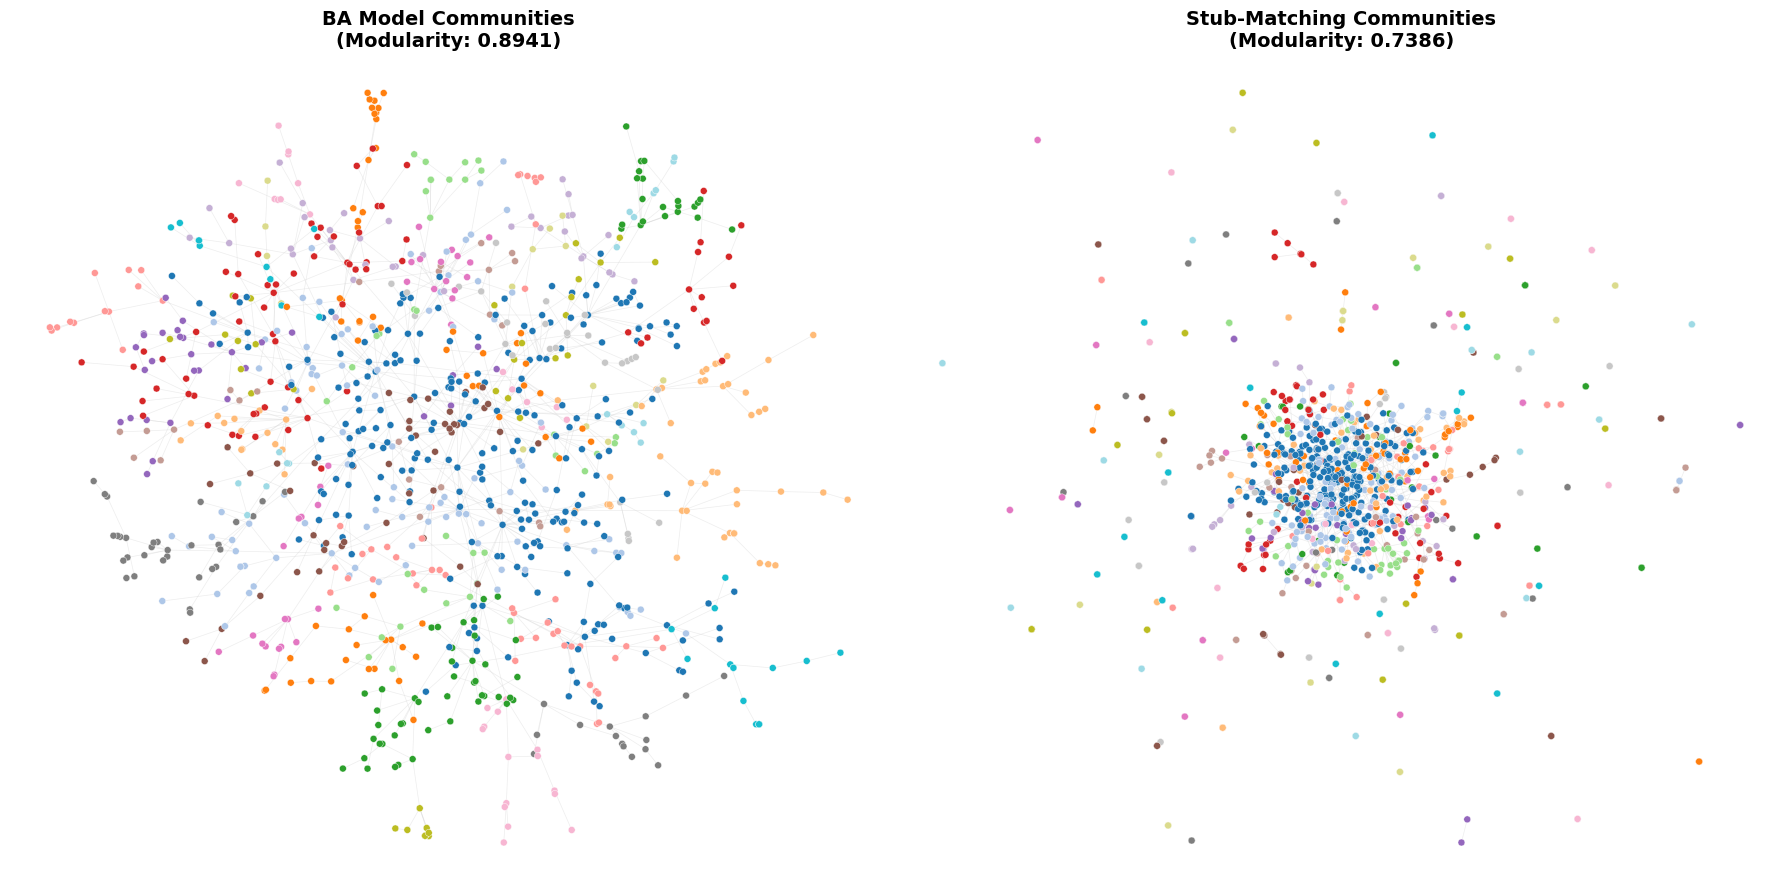

Final Modularity BA: 0.8941
Final Modularity Stub: 0.7386


In [16]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
import os

# Ensure the directory exists
os.makedirs('images', exist_ok=True)

# Generate networks
n = 1050
m = 1
print("Generating networks for 2(h)...")
g_ba = ig.Graph.Barabasi(n=n, m=m, directed=False)
deg_seq = g_ba.degree()
g_stub = ig.Graph.Degree_Sequence(deg_seq, method="simple")

# Community detection using Walktrap (robust for random graphs)
clusters_ba = g_ba.community_walktrap().as_clustering()
clusters_stub = g_stub.community_walktrap().as_clustering()

def plot_community_network(graph, clustering, ax, title):
    # Use Fruchterman-Reingold layout for better spacing
    layout = graph.layout_fruchterman_reingold()
    coords = np.array(layout.coords)
    
    # Draw Edges with lower alpha
    edges = graph.get_edgelist()
    lines = [(coords[u], coords[v]) for u, v in edges]
    lc = mcoll.LineCollection(lines, colors='lightgray', linewidths=0.5, alpha=0.4)
    ax.add_collection(lc)
    
    # Draw Nodes with Community Colors
    # Using 'Set1' or 'tab20' for distinct community marking
    membership = clustering.membership
    scatter = ax.scatter(coords[:, 0], coords[:, 1], c=membership, 
                         cmap='tab20', s=25, edgecolors='white', linewidth=0.3, zorder=3)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

plot_community_network(g_ba, clusters_ba, axes[0], 
                       f"BA Model Communities\n(Modularity: {clusters_ba.modularity:.4f})")
plot_community_network(g_stub, clusters_stub, axes[1], 
                       f"Stub-Matching Communities\n(Modularity: {clusters_stub.modularity:.4f})")

plt.tight_layout()
plt.savefig('images/part2_2h_community_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Modularity BA: {clusters_ba.modularity:.4f}")
print(f"Final Modularity Stub: {clusters_stub.modularity:.4f}")

Simulating BA networks for Expected Degree vs Age (m=1, 50 trials)...


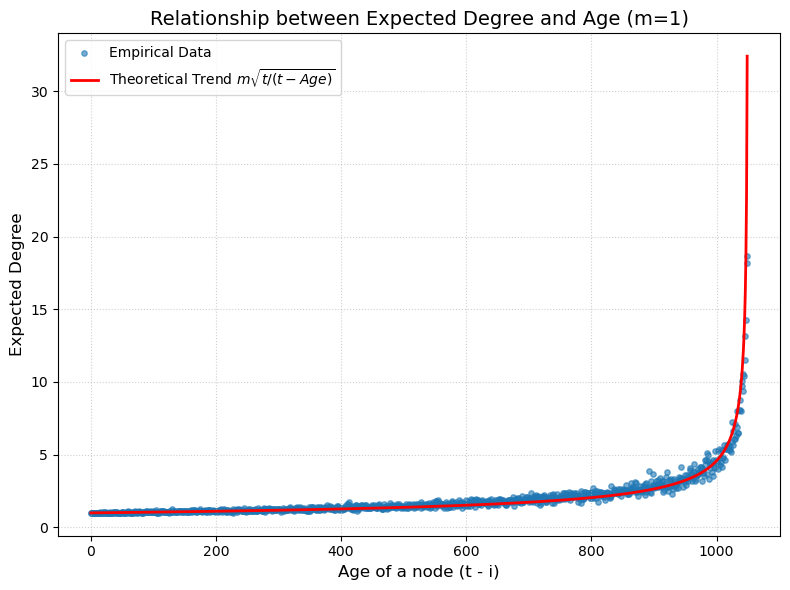

Plot successfully generated and saved as 'images/part2_2f_expected_degree_age_upward.png'


In [18]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

# Parameters for 2(f)
n_nodes = 1050
num_trials = 50
m_val = 1

print(f"Simulating BA networks for Expected Degree vs Age (m={m_val}, {num_trials} trials)...")
deg_matrix = np.zeros((num_trials, n_nodes))

# Generate 50 networks to find the expected (average) degree
for t in range(num_trials):
    deg_matrix[t, :] = ig.Graph.Barabasi(n=n_nodes, m=m_val, directed=False).degree()

expected_k = np.mean(deg_matrix, axis=0)

# Node indices 'i' represent the time step (1 to n_nodes)
# The oldest node is i=1, the newest node is i=1050.
i = np.arange(1, n_nodes + 1)

# Age is defined as the total time minus the time step of addition (t - i)
# Oldest node has age = 1049, newest node has age = 0
ages = n_nodes - i

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Empirical data
ax.scatter(ages, expected_k, color='tab:blue', s=15, alpha=0.6, label='Empirical Data')

# Theoretical curve: k_i(t) = m * sqrt(t/i) 
# Replacing i with (n_nodes - age)
theoretical_k = m_val * np.sqrt(n_nodes / (n_nodes - ages))
ax.plot(ages, theoretical_k, color='red', lw=2, label=r'Theoretical Trend $m\sqrt{t/(t-Age)}$')

ax.set_title(f"Relationship between Expected Degree and Age (m={m_val})", fontsize=14)
ax.set_xlabel("Age of a node (t - i)", fontsize=12)
ax.set_ylabel("Expected Degree", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig('images/part2_2f_expected_degree_age_upward.png', dpi=300)
plt.show()

print("Plot successfully generated and saved as 'images/part2_2f_expected_degree_age_upward.png'")

=== PART 2(g): REPEATING (a)-(e) FOR m=2, 6 ===
[m=2, n=1050 ] Connected: True | Modularity: 0.5272 | Assort: -0.0275 | Deg Slope: -2.4843 | Neigh Slope: -1.0632
[m=2, n=10500] Connected: True | Modularity: 0.5316 | Assort: -0.0084 | Deg Slope: -2.6937 | Neigh Slope: -1.4123
[m=6, n=1050 ] Connected: True | Modularity: 0.2508 | Assort: -0.0164 | Deg Slope: -2.1833 | Neigh Slope: -0.9872
[m=6, n=10500] Connected: True | Modularity: 0.2476 | Assort: -0.0004 | Deg Slope: -2.7024 | Neigh Slope: -1.1731

=== PART 2(g): REPEATING (f) FOR m=2, 6 ===
Saved 2(g) Age plot to images/part2_2g_age.png

=== PART 2(h): BA vs STUB-MATCHING ===
Modularity (Original BA)  : 0.8314
Modularity (Stub-Matching): 0.7351
Saved 2(h) Community plot to images/part2_2h_comm.png


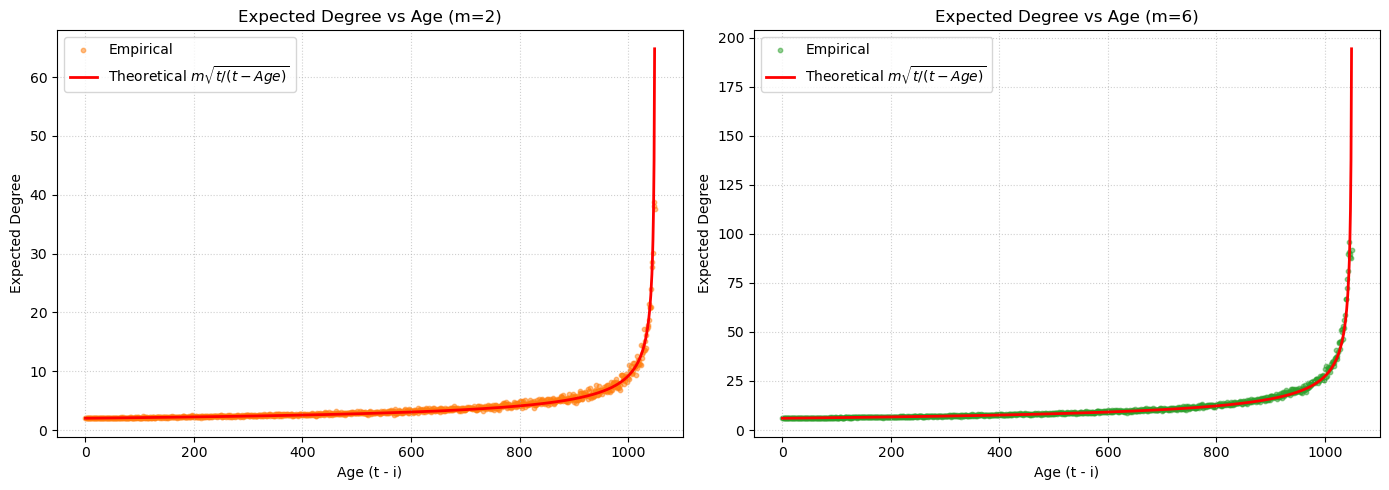

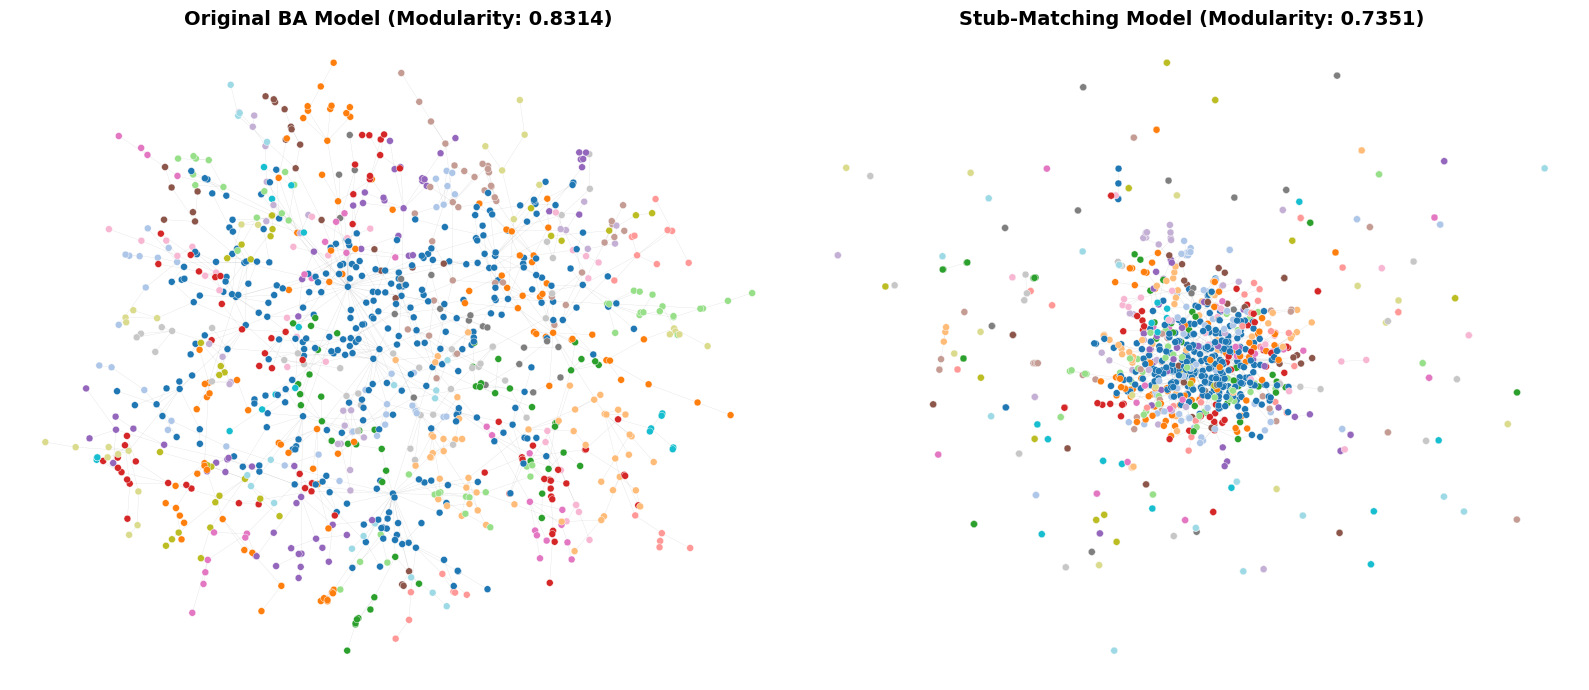

In [20]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
from collections import Counter
import os

os.makedirs('images', exist_ok=True)

def get_slopes(graph):
    # Standard degree distribution slope
    degrees = graph.degree()
    counts = Counter(degrees)
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[k] / graph.vcount() for k in x])
    valid = np.array([counts[k] >= 2 for k in x])
    if sum(valid) < 2: valid = np.array([counts[k] >= 1 for k in x])
    slope_deg, _ = np.polyfit(np.log10(x[valid]), np.log10(y[valid]), 1)
    
    # Neighbor degree distribution slope
    valid_nodes = np.where(np.array(degrees) > 0)[0]
    sampled_degrees = []
    for _ in range(50000):
        i = np.random.choice(valid_nodes)
        neighbors = graph.neighbors(i)
        if len(neighbors) > 0:
            j = np.random.choice(neighbors)
            sampled_degrees.append(degrees[j])
    counts_n = Counter(sampled_degrees)
    xn = np.array(sorted(counts_n.keys()))
    yn = np.array([counts_n[k] / len(sampled_degrees) for k in xn])
    valid_n = (xn > 0) & (yn > 0)
    slope_neigh, _ = np.polyfit(np.log10(xn[valid_n]), np.log10(yn[valid_n]), 1)
    
    return slope_deg, slope_neigh

print("=== PART 2(g): REPEATING (a)-(e) FOR m=2, 6 ===")
for m in [2, 6]:
    for n in [1050, 10500]:
        g = ig.Graph.Barabasi(n=n, m=m, directed=False)
        
        # (a) Connectivity
        is_conn = g.is_connected()
        
        # (b/c) Modularity & Assortativity
        g_simple = g.copy()
        g_simple.simplify(multiple=True, loops=True)
        mod = g_simple.community_fastgreedy().as_clustering().modularity
        assort = g.assortativity_degree()
        
        # (d/e) Slopes
        slope_d, slope_n = get_slopes(g)
        
        print(f"[m={m}, n={n:<5}] Connected: {is_conn} | Modularity: {mod:.4f} | Assort: {assort:.4f} | Deg Slope: {slope_d:.4f} | Neigh Slope: {slope_n:.4f}")

print("\n=== PART 2(g): REPEATING (f) FOR m=2, 6 ===")
n_nodes = 1050
num_trials = 50
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, m in enumerate([2, 6]):
    deg_matrix = np.zeros((num_trials, n_nodes))
    for t in range(num_trials):
        deg_matrix[t, :] = ig.Graph.Barabasi(n=n_nodes, m=m, directed=False).degree()
    exp_k = np.mean(deg_matrix, axis=0)
    ages = n_nodes - np.arange(1, n_nodes + 1)
    
    ax = axes[idx]
    ax.scatter(ages, exp_k, color='tab:orange' if m==2 else 'tab:green', s=10, alpha=0.5, label='Empirical')
    ax.plot(ages, m * np.sqrt(n_nodes / (n_nodes - ages)), color='red', lw=2, label=r'Theoretical $m\sqrt{t/(t-Age)}$')
    ax.set_title(f"Expected Degree vs Age (m={m})")
    ax.set_xlabel("Age (t - i)")
    ax.set_ylabel("Expected Degree")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
plt.tight_layout()
plt.savefig('images/part2_2g_age.png', dpi=300)
print("Saved 2(g) Age plot to images/part2_2g_age.png")

print("\n=== PART 2(h): BA vs STUB-MATCHING ===")
g_ba = ig.Graph.Barabasi(n=1050, m=1, directed=False)
g_stub = ig.Graph.Degree_Sequence(g_ba.degree(), method="simple")

c_ba = g_ba.community_walktrap().as_clustering()
c_stub = g_stub.community_walktrap().as_clustering()
print(f"Modularity (Original BA)  : {c_ba.modularity:.4f}")
print(f"Modularity (Stub-Matching): {c_stub.modularity:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
def plot_comm(graph, clustering, ax, title):
    layout = graph.layout_fruchterman_reingold()
    coords = np.array(layout.coords)
    edges = [(coords[u], coords[v]) for u, v in graph.get_edgelist()]
    ax.add_collection(mcoll.LineCollection(edges, colors='gray', lw=0.2, alpha=0.3))
    ax.scatter(coords[:, 0], coords[:, 1], c=clustering.membership, cmap='tab20', s=25, edgecolors='white', linewidth=0.3, zorder=3)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

plot_comm(g_ba, c_ba, axes[0], f"Original BA Model (Modularity: {c_ba.modularity:.4f})")
plot_comm(g_stub, c_stub, axes[1], f"Stub-Matching Model (Modularity: {c_stub.modularity:.4f})")
plt.tight_layout()
plt.savefig('images/part2_2h_comm.png', dpi=300)
print("Saved 2(h) Community plot to images/part2_2h_comm.png")

Generating Age-Penalized BA Network (Custom Implementation)...

PART 3 RESULTS
[Part 3a] Estimated Power-law Exponent (Slope) : -2.5778
[Part 3b] Modularity (Fast Greedy)             : 0.9379



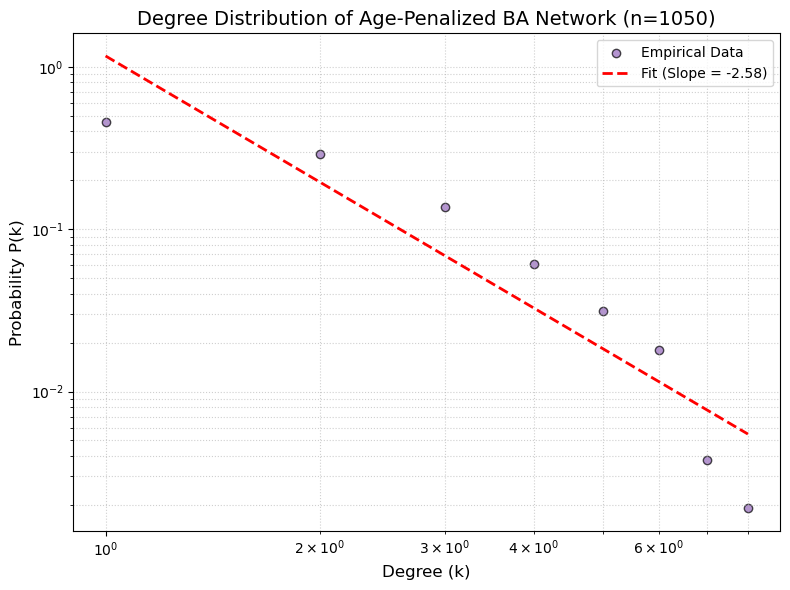

In [14]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

os.makedirs('images', exist_ok=True)

# --- Custom Age-Penalized BA Generator ---
def generate_age_penalized_ba(n, m=1):
    g = ig.Graph(directed=False)
    g.add_vertices(n) 
    
    # Track degrees using a numpy array for performance
    degrees = np.zeros(n)
    edges = []
    
    for t in range(1, n):
        # The new node t can connect to any existing node from 0 to t-1
        i_array = np.arange(t)
        
        # Calculate the age of each existing node (current time t minus birth time i)
        ages = t - i_array
        
        # Retrieve the current degree of each existing node
        k_array = degrees[:t]
        
        # Core formula: P[i] is proportional to (k_i + 1) / age_i
        probs = (k_array + 1) / ages
        
        # Normalize probabilities so they sum to 1
        probs = probs / np.sum(probs)
        
        # Select m distinct targets based on the calculated probabilities
        targets = np.random.choice(i_array, size=m, replace=False, p=probs)
        
        for target in targets:
            edges.append((t, target))
            degrees[target] += 1
        degrees[t] += m
        
    g.add_edges(edges)
    return g

# --- 1. Network Generation ---
print("Generating Age-Penalized BA Network (Custom Implementation)...")
n_nodes = 1050
m_val = 1
g_age = generate_age_penalized_ba(n_nodes, m_val)

# --- 2. Calculate Power-law Exponent (Part 3a) ---
degrees = g_age.degree()
counts = Counter(degrees)
x = np.array(sorted(counts.keys()))
y = np.array([counts[k] / n_nodes for k in x])

# Filter out tail noise (keep degrees appearing at least twice for robust fitting)
valid = np.array([counts[k] >= 2 for k in x])
if sum(valid) < 2:  # Fallback if the distribution is extremely sparse
    valid = np.array([counts[k] >= 1 for k in x])

log_x = np.log10(x[valid])
log_y = np.log10(y[valid])
slope, intercept = np.polyfit(log_x, log_y, 1)

# --- 3. Calculate Community Structure (Part 3b) ---
# Ensure the network is simplified before community detection
g_age.simplify(multiple=True, loops=True)
modularity = g_age.community_fastgreedy().as_clustering().modularity

# --- 4. Print All Results BEFORE Plotting ---
print("\n" + "="*40)
print("PART 3 RESULTS")
print("="*40)
print(f"[Part 3a] Estimated Power-law Exponent (Slope) : {slope:.4f}")
print(f"[Part 3b] Modularity (Fast Greedy)             : {modularity:.4f}")
print("="*40 + "\n")

# --- 5. Plotting (Part 3a) ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='tab:purple', alpha=0.7, edgecolors='k', label='Empirical Data')

# Fit line
fit_x = x[valid]
fit_y = (10**intercept) * (fit_x**slope)
ax.plot(fit_x, fit_y, 'r--', lw=2, label=f'Fit (Slope = {slope:.2f})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Degree Distribution of Age-Penalized BA Network (n=1050)", fontsize=14)
ax.set_xlabel("Degree (k)", fontsize=12)
ax.set_ylabel("Probability P(k)", fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.savefig('images/part3_3a_degree_distribution.png', dpi=300)
plt.show()